In [135]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)
import joblib

In [37]:
input_data = pd.read_csv(r'Churn_Modelling.csv')
input_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
input_data.describe()
input_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [39]:
input_data.drop(['RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)
input_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [40]:
input_data['Gender'] = le.fit_transform(input_data['Gender'])
input_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [41]:
input_data = pd.get_dummies(input_data, columns = ['Geography'], drop_first=True)
input_data

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,False,False
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,False,False
9997,709,0,36,7,0.00,1,0,1,42085.58,1,False,False
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,True,False


In [43]:
input_data['Geography_Germany'] = input_data['Geography_Germany'].astype(int)
input_data['Geography_Spain'] = input_data['Geography_Spain'].astype(int)
input_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


<Axes: xlabel='Exited', ylabel='count'>

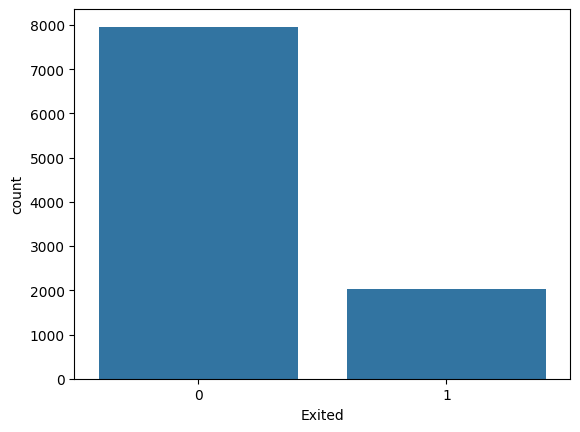

In [45]:
# Target distribution
sns.countplot(x='Exited', data=input_data)

<Axes: xlabel='Age', ylabel='Count'>

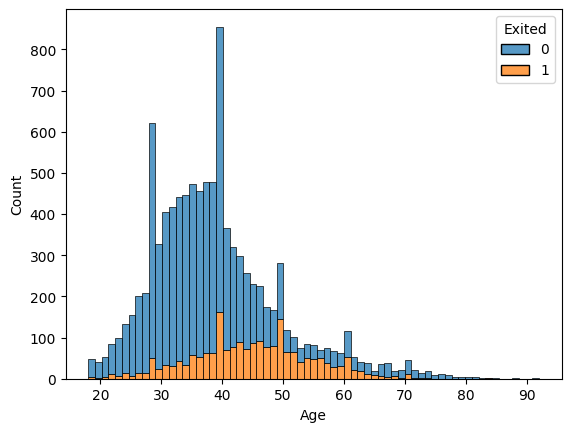

In [49]:
sns.histplot(x='Age', hue='Exited', data=input_data, multiple='stack')

<Axes: xlabel='Exited', ylabel='CreditScore'>

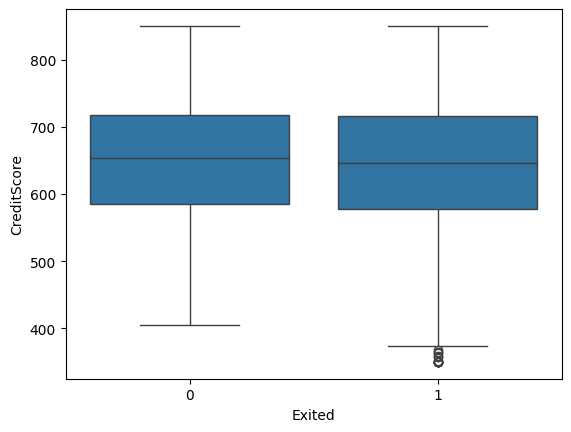

In [56]:
sns.boxplot(x='Exited', y='CreditScore', data=input_data)

<Axes: xlabel='Gender', ylabel='count'>

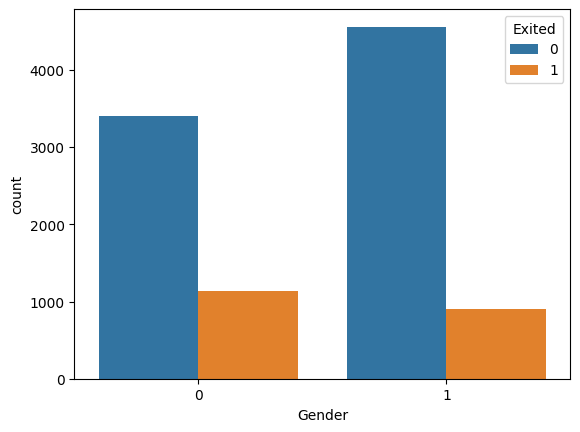

In [58]:
sns.countplot(x='Gender', hue='Exited', data=input_data)

<Axes: xlabel='Balance', ylabel='Count'>

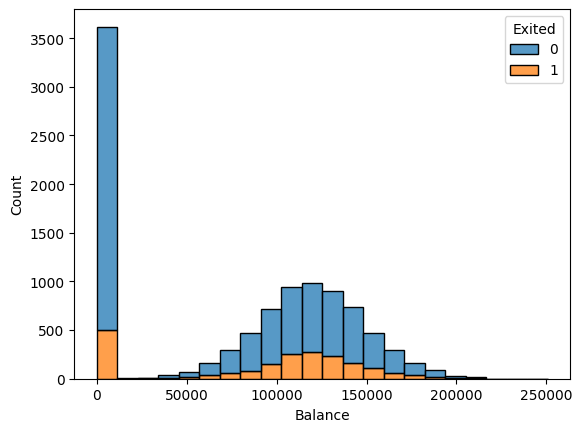

In [59]:
sns.histplot(x='Balance', hue='Exited', data=input_data, multiple='stack')

<Axes: xlabel='NumOfProducts', ylabel='Exited'>

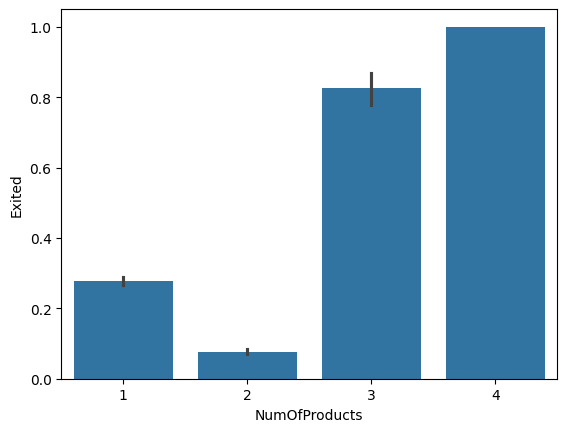

In [60]:
sns.barplot(x='NumOfProducts', y='Exited', data=input_data)

<Axes: >

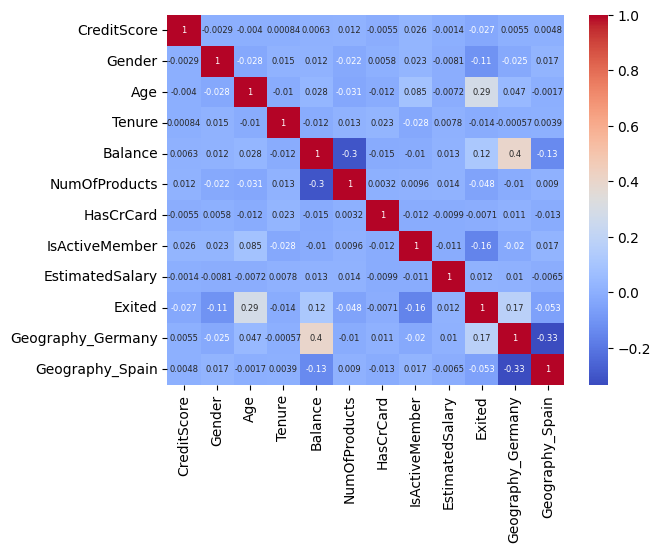

In [69]:
corr = input_data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', annot_kws={'size':6})

In [90]:
x=input_data.drop(['Exited'], axis=1)
y=input_data['Exited']

In [91]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=45
)

In [92]:
#Sclaing the data to make it easy to be understood by the neural network.
std_sclr = StandardScaler()
x_train = std_sclr.fit_transform(x_train)
x_test = std_sclr.transform(x_test)

# Creating a neural network for Binary Classification and training it with x_train/y_train

In [114]:
model = keras.models.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

In [115]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [116]:
trained_mod = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.1) #by default batch size is 32 only.

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7040 - loss: 0.5903 - val_accuracy: 0.8125 - val_loss: 0.4409
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8153 - loss: 0.4423 - val_accuracy: 0.8325 - val_loss: 0.3966
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8243 - loss: 0.4156 - val_accuracy: 0.8487 - val_loss: 0.3767
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8297 - loss: 0.4021 - val_accuracy: 0.8512 - val_loss: 0.3713
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8356 - loss: 0.3910 - val_accuracy: 0.8487 - val_loss: 0.3741
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8407 - loss: 0.3807 - val_accuracy: 0.8487 - val_loss: 0.3685
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8453 - loss: 0.3721 - val_accuracy: 0.8512 - val_loss: 0.3661
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8435 - loss: 0.3707 - val_accu

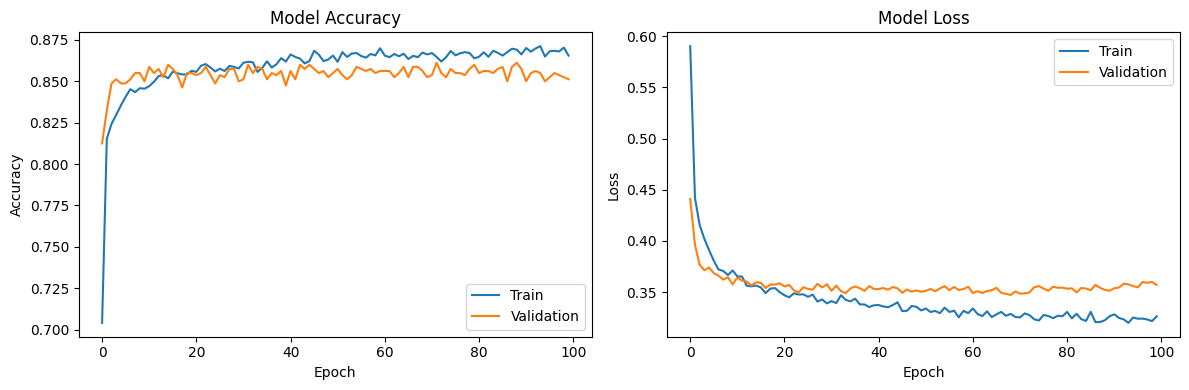

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(trained_mod.history['accuracy'], label='Train')
axes[0].plot(trained_mod.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(trained_mod.history['loss'], label='Train')
axes[1].plot(trained_mod.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

In [125]:
y_pred = model.predict(x_test)
y_pred = (y_pred>0.5).astype(int)
y_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[0],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [131]:
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(f"Classification report: {classification_report(y_test, y_pred)}")

Test Accuracy: 0.8585

Classification report:               precision    recall  f1-score   support

           0       0.87      0.96      0.92      1581
           1       0.77      0.46      0.58       419

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.84      2000



In [138]:
model.save('BankChurnPredictor.keras') #saving model for future use.
joblib.dump(std_sclr, 'scaler.pkl') #saving scaler also for future use

['scaler.pkl']